In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(r"C:\Users\08300\Downloads\archive (6)\diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
df.drop(columns=['weight', 'payer_code', 'medical_specialty', 'encounter_id', 'patient_nbr'], inplace=True)
df.head()
print(df.shape)

(101766, 45)


In [5]:
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'insulin', 'tolbutamide']

df['total_meds_changes'] = df[med_cols].apply(
    lambda x: ((x == 'Up') | (x == 'Down')).sum(), axis=1
)

df.drop(columns=med_cols, inplace=True)

df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,total_meds_changes
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,NO,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,No,No,No,No,No,Ch,Yes,>30,1
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,Yes,NO,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,No,No,No,No,No,Ch,Yes,NO,1
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,No,No,No,No,No,Ch,Yes,NO,0


In [6]:
print(df.shape)

(101766, 34)


In [7]:
print(df.dtypes)

race                        object
gender                      object
age                         object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
acetohexamide               object
miglitol                    object
troglitazone                object
tolazamide                  object
examide                     object
citoglipton                 object
glyburide-metformin         object
glipizide-metformin         object
glimepiride-pioglitazone    object
metformin-rosiglitaz

In [8]:
print(df.isnull().sum())

race                            0
gender                          0
age                             0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
acetohexamide                   0
miglitol                        0
troglitazone                    0
tolazamide                      0
examide                         0
citoglipton                     0
glyburide-metformin             0
glipizide-metformin             0
glimepiride-pioglitazone        0
metformin-rosiglitazone         0
metformin-piog

In [9]:
df['max_glu_serum'].fillna('None', inplace=True)
df['A1Cresult'].fillna('None', inplace=True)

C:\Users\08300\AppData\Local\Temp\ipykernel_16480\3740675088.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['max_glu_serum'].fillna('None', inplace=True)
C:\Users\08300\AppData\Local\Temp\ipykernel_16480\3740675088.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [10]:
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'insulin', 'tolbutamide',
            'acetohexamide', 'miglitol', 'troglitazone', 'tolazamide',
            'examide', 'citoglipton', 'glyburide-metformin', 
            'glipizide-metformin', 'glimepiride-pioglitazone',
            'metformin-rosiglitazone', 'metformin-pioglitazone']

med_cols_present = [col for col in med_cols if col in df.columns]
df.drop(columns=med_cols_present, inplace=True)

In [11]:
print(df.isnull().sum())
print(df.shape)

race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
change                      0
diabetesMed                 0
readmitted                  0
total_meds_changes          0
dtype: int64
(101766, 23)


In [12]:
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)
df.drop(columns=('readmitted'), inplace=True)

print(df['readmitted_30'].value_counts())
print(df['readmitted_30'].value_counts(normalize=True).round(3))

readmitted_30
0    90409
1    11357
Name: count, dtype: int64
readmitted_30
0    0.888
1    0.112
Name: proportion, dtype: float64


In [13]:
## Class Imbalance Note
# - 88.8% not readmitted within 30 days
# - 11.2% readmitted within 30 days
# - Dataset is imbalanced ~8:1 ratio
# - Will address with class_weight='balanced' during modeling phase

C:\Users\08300\AppData\Local\Temp\ipykernel_16480\1193080449.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_readmit, x='age', y='readmitted_30', palette='Blues_d')


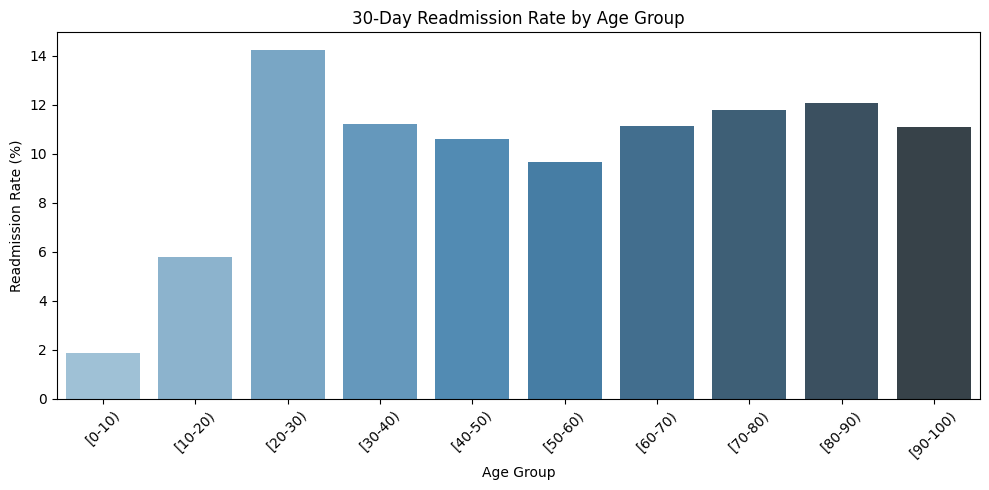

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

age_readmit = df.groupby('age')['readmitted_30'].mean().reset_index()
age_readmit['readmitted_30'] = age_readmit['readmitted_30'] * 100

plt.figure(figsize=(10, 5))
sns.barplot(data=age_readmit, x='age', y='readmitted_30', palette='Blues_d')
plt.title('30-Day Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

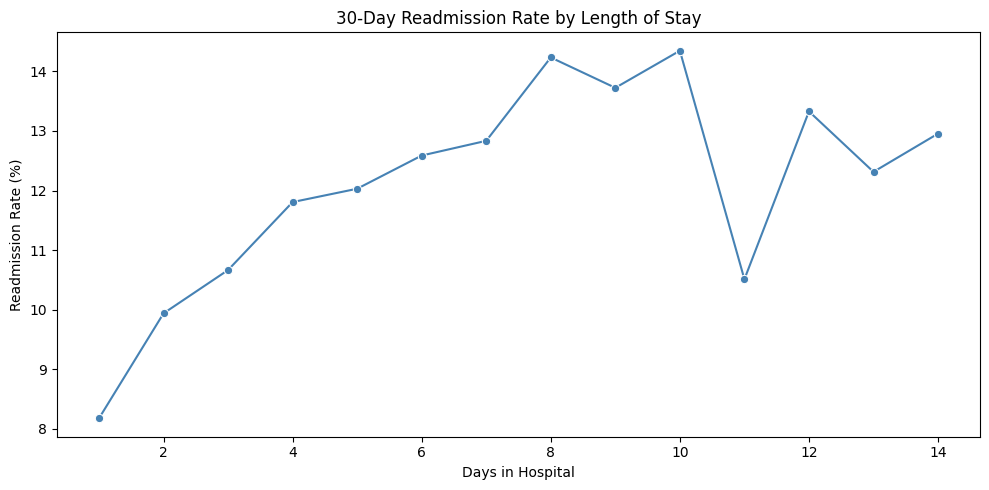

In [15]:
time_readmit = df.groupby('time_in_hospital')['readmitted_30'].mean().reset_index()
time_readmit['readmitted_30'] = time_readmit['readmitted_30'] * 100

plt.figure(figsize=(10, 5))
sns.lineplot(data=time_readmit, x='time_in_hospital', y='readmitted_30', marker='o', color='steelblue')
plt.title('30-Day Readmission Rate by Length of Stay')
plt.xlabel('Days in Hospital')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.show()

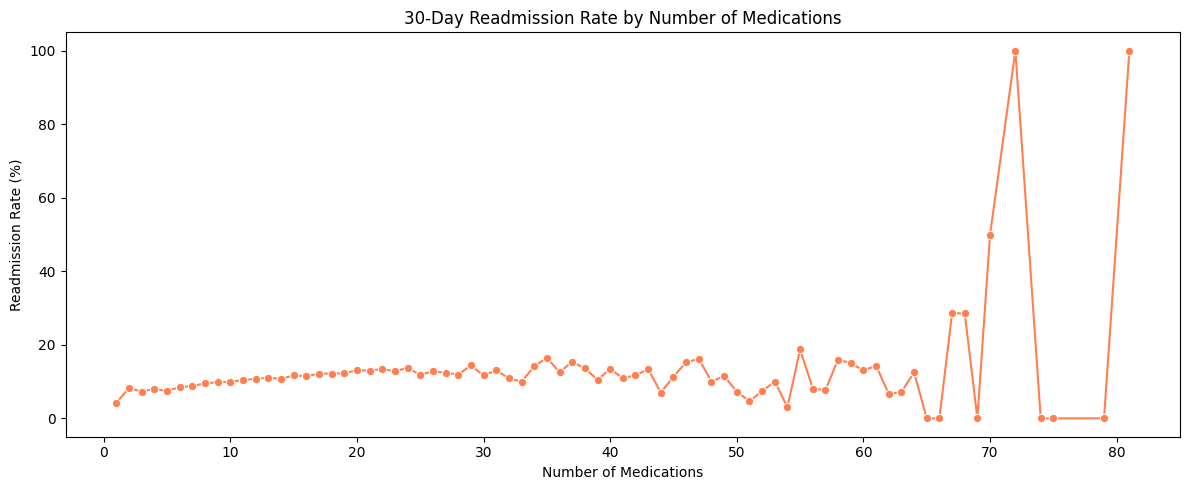

In [16]:
med_readmit = df.groupby('num_medications')['readmitted_30'].mean().reset_index()
med_readmit['readmitted_30'] = med_readmit['readmitted_30'] * 100

plt.figure(figsize=(12, 5))
sns.lineplot(data=med_readmit, x='num_medications', y='readmitted_30', marker='o', color='coral')
plt.title('30-Day Readmission Rate by Number of Medications')
plt.xlabel('Number of Medications')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.show()

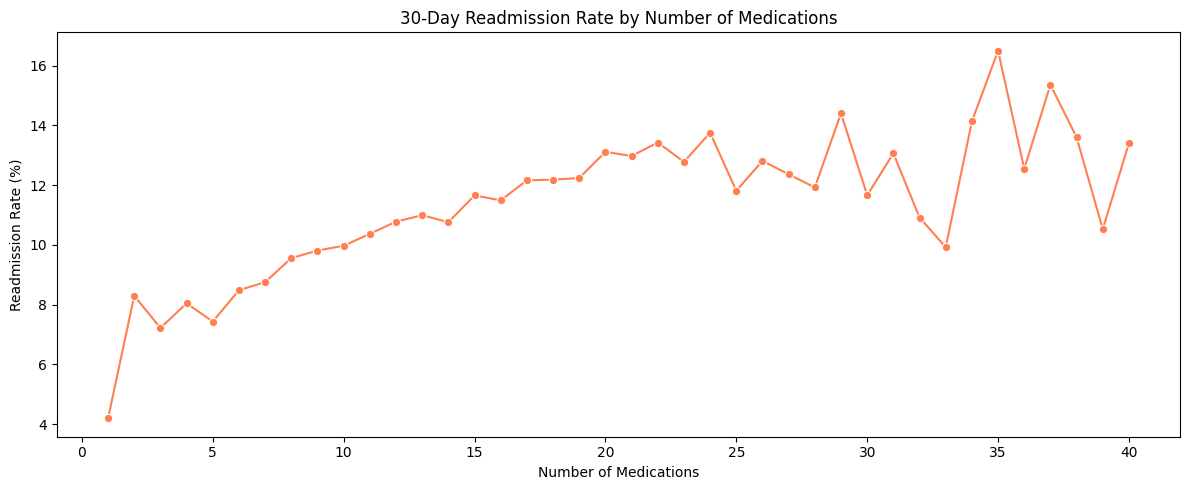

In [17]:
med_readmit_filtered = med_readmit[med_readmit['num_medications'] <= 40]

plt.figure(figsize=(12, 5))
sns.lineplot(data=med_readmit_filtered, x='num_medications', y='readmitted_30', marker='o', color='coral')
plt.title('30-Day Readmission Rate by Number of Medications')
plt.xlabel('Number of Medications')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.show()

In [18]:
## Key Finding — Medications
# Readmission risk rises sharply as medication count increases from 0 to 20,
# then plateaus around 12-14%. Patients on 15+ medications represent a 
# consistently high-risk segment worth flagging for care management intervention.

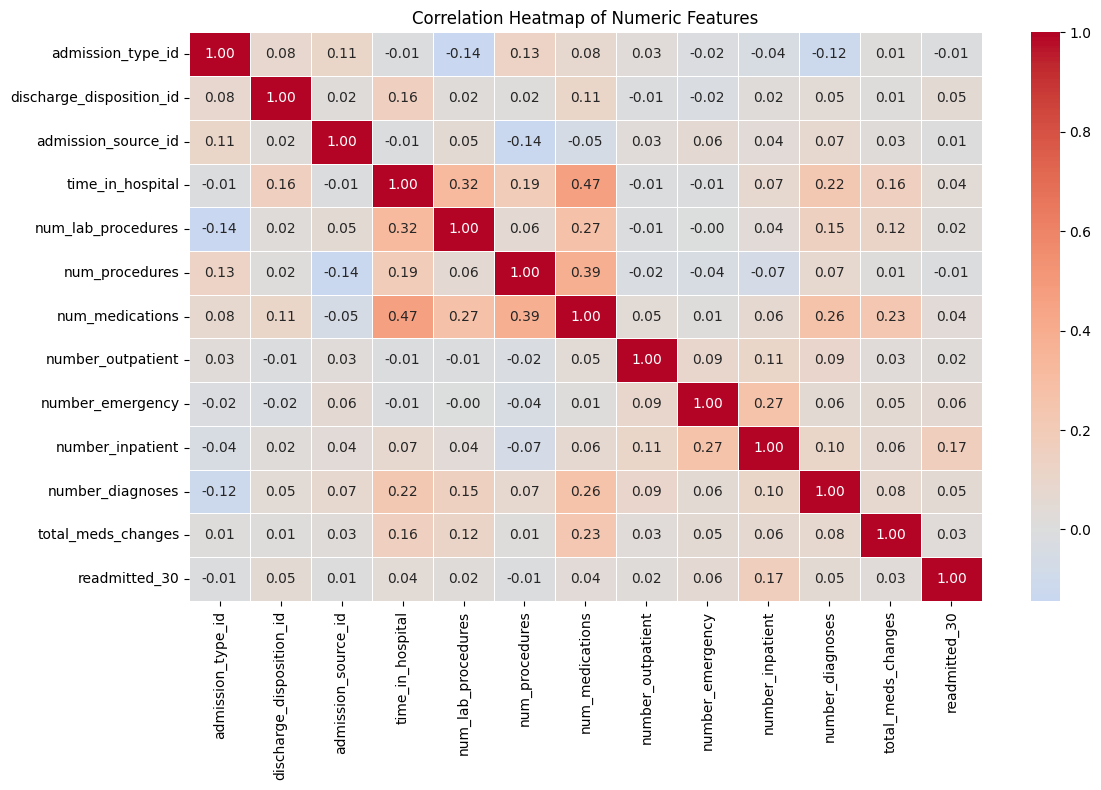

In [19]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidth=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

## Correlation Findings
- number_inpatient is the strongest numeric predictor of 30-day readmission (r=0.17)
- Overall correlations with readmitted_30 are low, suggesting:
  1. Readmission is driven by non-linear relationships
  2. Categorical features (diagnosis codes, age, medications) likely carry more signal
  3. A tree-based model (Random Forest) will likely outperform linear models

In [20]:
import sqlite3

conn = sqlite3.connect('hospital_readmission.db')
df.to_sql('patients', conn, if_exists='replace', index=False)

print("Database successfully created")
print(f"Rows loaded: {len(df)}")

Database successfully created
Rows loaded: 101766


In [21]:
def run_query(sql):
    return pd.read_sql_query(sql, conn)

In [22]:
run_query("""
    SELECT COUNT(*) as total_patients,
      SUM(readmitted_30) as total_readmitted,
      ROUND(AVG(readmitted_30) * 100, 2) as readmit_rate_pct
    FROM patients
""")

,total_patients,total_readmitted,readmit_rate_pct
0,101766,11357,11.16


In [23]:
run_query("""
    SELECT age,
          COUNT(*) as total_patients,
          SUM(readmitted_30) as readmitted,
          ROUND(AVG(readmitted_30) * 100, 2) as readmit_rate_pct
    FROM patients
    GROUP BY age
    ORDER BY readmit_rate_pct DESC
""")

,age,total_patients,readmitted,readmit_rate_pct
0,[20-30),1657,236,14.24
1,[80-90),17197,2078,12.08
2,[70-80),26068,3069,11.77
3,[30-40),3775,424,11.23
4,[60-70),22483,2502,11.13
5,[90-100),2793,310,11.10
6,[40-50),9685,1027,10.60
7,[50-60),17256,1668,9.67
8,[10-20),691,40,5.79
9,[0-10),161,3,1.86


In [24]:
run_query("""
    SELECT number_inpatient,
          COUNT(*) as total_patients,
          SUM(readmitted_30) as readmitted,
          ROUND(AVG(readmitted_30) * 100, 2) as readmit_rate_pct
    FROM patients
    GROUP BY number_inpatient
    ORDER BY number_inpatient
""")


,number_inpatient,total_patients,readmitted,readmit_rate_pct
0,0,67630,5706,8.44
1,1,19521,2523,12.92
2,2,7566,1319,17.43
3,3,3411,692,20.29
4,4,1622,383,23.61
5,5,812,255,31.40
6,6,480,166,34.58
7,7,268,95,35.45
8,8,151,67,44.37
9,9,111,47,42.34


In [25]:
run_query("""
    SELECT diabetesMed,
          COUNT(*) as total_patients,
          SUM(readmitted_30) as readmitted,
          ROUND(AVG(readmitted_30) * 100, 2) as readmit_rate_pct
    FROM patients
    GROUP BY diabetesMed
    ORDER BY readmit_rate_pct DESC
""")

,diabetesMed,total_patients,readmitted,readmit_rate_pct
0,Yes,78363,9111,11.63
1,No,23403,2246,9.60


In [26]:
run_query("""
    SELECT diag_1,
          COUNT(*) as total_patients,
          SUM(readmitted_30) as readmitted,
          ROUND(AVG(readmitted_30) * 100, 2) as readmit_rate_pct
    FROM patients
    GROUP BY diag_1
    HAVING COUNT(*) > 100
    ORDER BY readmit_rate_pct DESC
    LIMIT 10
""")

,diag_1,total_patients,readmitted,readmit_rate_pct
0,V58,228,95,41.67
1,443,110,24,21.82
2,593,101,21,20.79
3,572,239,49,20.50
4,202,104,20,19.23
5,250.7,871,165,18.94
6,790,144,27,18.75
7,250.6,1183,219,18.51
8,787,267,49,18.35
9,707,257,43,16.73


In [27]:
run_query("""
    SELECT 
        CASE 
            WHEN number_inpatient >= 3 THEN 'High Risk'
            WHEN number_inpatient >= 1 THEN 'Medium Risk'
            ELSE 'Low Risk'
        END as risk_tier,
        COUNT(*) as total_patients,
        SUM(readmitted_30) as readmitted,
        ROUND(AVG(readmitted_30) * 100, 2) as readmit_rate_pct
    FROM patients
    GROUP BY risk_tier
    ORDER BY readmit_rate_pct DESC
""")

,risk_tier,total_patients,readmitted,readmit_rate_pct
0,High Risk,7049,1809,25.66
1,Medium Risk,27087,3842,14.18
2,Low Risk,67630,5706,8.44


In [28]:
print("Notebook checkpoint!")
print(f"Dataset shape: {df.shape}")
print(f"Total readmitted: {df['readmitted_30'].sum()}")
print(f"Readmission rate: {df['readmitted_30'].mean():.2%}")

Notebook checkpoint!
Dataset shape: (101766, 23)
Total readmitted: 11357
Readmission rate: 11.16%


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = df.drop(columns=['readmitted_30'])
y = df['readmitted_30']

cat_cols = X.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print("Features shape", X.shape)
print("Target shape", y.shape)

Features shape (101766, 22)
Target shape (101766,)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Train readmission rate:", y_train.mean().round(4))
print("Test readmission rate:", y_test.mean().round(4))

Training set: (81412, 22)
Test set: (20354, 22)
Train readmission rate: 0.1116
Test readmission rate: 0.1116


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_probs):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.92      0.70      0.79     18083
           1       0.17      0.51      0.26      2271

    accuracy                           0.67     20354
   macro avg       0.55      0.60      0.52     20354
weighted avg       0.83      0.67      0.73     20354

ROC-AUC Score: 0.6449


c:\Users\08300\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_probs):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.68      0.01      0.01      2271

    accuracy                           0.89     20354
   macro avg       0.79      0.50      0.48     20354
weighted avg       0.87      0.89      0.84     20354

ROC-AUC Score: 0.6564


In [33]:
rf_model_v2 = RandomForestClassifier(
    n_estimators=100,
    class_weight={0: 1, 1: 8},  # manually weight minority class
    max_depth=10,                # prevent overfitting
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1)

rf_model_v2.fit(X_train, y_train)

rf_preds_v2 = rf_model_v2.predict(X_test)
rf_probs_v2 = rf_model_v2.predict_proba(X_test)[:, 1]

print("=== Random Forest v2 ===")
print(classification_report(y_test, rf_preds_v2))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_probs_v2):.4f}")

=== Random Forest v2 ===
              precision    recall  f1-score   support

           0       0.93      0.70      0.80     18083
           1       0.19      0.56      0.28      2271

    accuracy                           0.68     20354
   macro avg       0.56      0.63      0.54     20354
weighted avg       0.84      0.68      0.74     20354

ROC-AUC Score: 0.6721


## Model Comparison
- Logistic Regression: ROC-AUC 0.64, Recall 0.51
- Random Forest v1: ROC-AUC 0.66, Recall 0.01 (failed on minority class)
- Random Forest v2: ROC-AUC 0.67, Recall 0.56 (best overall)

Random Forest v2 selected as final model. Manual class weighting of 8:1
outperformed balanced weighting for this imbalanced dataset.

C:\Users\08300\AppData\Local\Temp\ipykernel_16480\3498376494.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importance, x='importance', y='feature', palette='Blues_r')


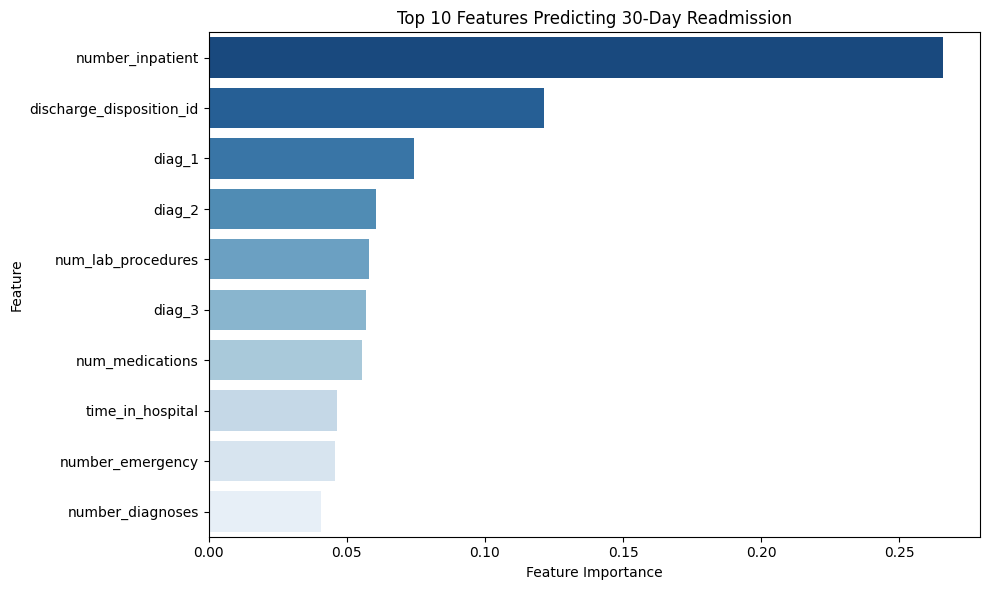

In [34]:
feat_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model_v2.feature_importances_
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance, x='importance', y='feature', palette='Blues_r')
plt.title('Top 10 Features Predicting 30-Day Readmission')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Key Model Finding
number_inpatient is the dominant predictor of 30-day readmission,
with ~3x the importance of the next feature. Patients with prior 
inpatient visits should be flagged immediately for care management 
intervention upon discharge.

In [35]:
#df.to_csv('hospital_readmission_clean.csv', index=False)

#feat_importance.to_csv('feature_importance.csv', index=False)

#age_readmit.to_csv('age_readmit.csv', index=False)

#print("All files exported successfully!")

In [40]:
# Risk tier summary
risk_summary = df.groupby(
    df['number_inpatient'].apply(
        lambda x: 'High Risk' if x >= 3 else ('Medium Risk' if x >= 1 else 'Low Risk')
    )
).agg(
    Total_Patients=('readmitted_30', 'count'),
    Total_Readmitted=('readmitted_30', 'sum'),
    Readmission_Rate=('readmitted_30', 'mean')
).reset_index()
risk_summary.columns = ['Risk Tier', 'Total Patients', 'Total Readmitted', 'Readmission Rate']
risk_summary['Readmission Rate'] = (risk_summary['Readmission Rate'] * 100).round(2)
risk_summary.to_csv('risk_summary.csv', index=False)

# Age summary
age_summary = df.groupby('age').agg(
    Total_Patients=('readmitted_30', 'count'),
    Total_Readmitted=('readmitted_30', 'sum'),
    Readmission_Rate=('readmitted_30', 'mean')
).reset_index()
age_summary.columns = ['Age Group', 'Total Patients', 'Total Readmitted', 'Readmission Rate']
age_summary['Readmission Rate'] = (age_summary['Readmission Rate'] * 100).round(2)
age_summary.to_csv('age_summary.csv', index=False)

print("Files exported!")

Files exported!


In [41]:
print(df.shape)
print(df.columns.tolist())

(101766, 23)
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed', 'total_meds_changes', 'readmitted_30']
